In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [4]:
INPUT_PATH = "../../data_lake/ml/datasets/df_features.parquet"

In [5]:
df = pd.read_parquet(INPUT_PATH)

In [6]:
df

,is_late_delivery,purchase_month,purchase_weekday,log_price,log_freight,log_weight,log_volume,freight_ratio,product_category_name_alimentos,product_category_name_alimentos_bebidas,...,route_SP_RJ,route_SP_RN,route_SP_RO,route_SP_RR,route_SP_RS,route_SP_SC,route_SP_SE,route_SP_SP,route_SP_TO,distance_km
0,0,11,4,4.007151,2.780681,5.303305,8.110427,0.275141,0,0,...,0,0,0,0,0,0,0,0,0,635.744707
1,0,7,6,5.484382,2.858193,5.817111,8.004032,0.068203,0,0,...,1,0,0,0,0,0,0,0,0,415.162198
2,0,11,4,4.769837,2.866762,7.467942,8.412055,0.140628,0,0,...,0,0,0,0,0,0,0,0,0,321.417852
3,1,2,0,4.934474,2.707383,7.090910,9.384966,0.100647,0,0,...,0,0,0,0,0,0,0,1,0,422.644042
4,0,8,1,4.393214,2.963209,7.346655,8.909370,0.226947,0,0,...,0,0,0,0,0,0,0,0,0,343.755693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95632,0,5,2,5.175585,2.721953,6.685861,8.428799,0.080328,0,0,...,0,0,0,0,0,0,0,0,0,1381.829088
95633,0,8,5,4.393214,2.423917,7.509883,9.949655,0.127194,0,0,...,0,0,0,0,0,0,0,1,0,314.724516
95634,0,4,1,4.393214,3.219276,9.047939,10.832221,0.296786,0,0,...,0,0,0,0,0,1,0,0,0,784.304128
95635,0,4,1,4.393214,3.219276,8.916104,10.832221,0.296786,0,0,...,0,0,0,0,0,1,0,0,0,784.304128


In [7]:
X = df.drop(columns=["is_late_delivery"])
y = df["is_late_delivery"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [9]:
continuous_cols = [
    "log_price",
    "log_freight",
    "log_weight",
    "log_volume",
    "freight_ratio",
    "distance_km"
]

In [10]:
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

In [11]:
X_train.columns.tolist()

['purchase_month',
 'purchase_weekday',
 'log_price',
 'log_freight',
 'log_weight',
 'log_volume',
 'freight_ratio',
 'product_category_name_alimentos',
 'product_category_name_alimentos_bebidas',
 'product_category_name_artes',
 'product_category_name_artes_e_artesanato',
 'product_category_name_artigos_de_festas',
 'product_category_name_artigos_de_natal',
 'product_category_name_audio',
 'product_category_name_automotivo',
 'product_category_name_bebes',
 'product_category_name_bebidas',
 'product_category_name_beleza_saude',
 'product_category_name_brinquedos',
 'product_category_name_cama_mesa_banho',
 'product_category_name_casa_conforto',
 'product_category_name_casa_conforto_2',
 'product_category_name_casa_construcao',
 'product_category_name_cds_dvds_musicais',
 'product_category_name_cine_foto',
 'product_category_name_climatizacao',
 'product_category_name_consoles_games',
 'product_category_name_construcao_ferramentas_construcao',
 'product_category_name_construcao_ferram

In [12]:
import numpy as np

df["month_sin"] = np.sin(2*np.pi*df["purchase_month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["purchase_month"]/12)

df.drop(columns=["purchase_month"], inplace=True)

In [13]:
df["weekday_sin"] = np.sin(2*np.pi*df["purchase_weekday"]/7)
df["weekday_cos"] = np.cos(2*np.pi*df["purchase_weekday"]/7)

df.drop(columns=["purchase_weekday"], inplace=True)

In [14]:
# Modelo
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [15]:
model.coef_

array([[-0.02485616, -0.03798067,  0.06066028,  0.04235258,  0.07630973,
         0.00719749, -0.01998946,  0.78578957,  0.10918622,  0.39525578,
         0.59523651, -1.73112464,  0.29090487,  0.72795185,  0.36527818,
         0.45700337,  0.42259175,  0.32738949,  0.28126275,  0.31734808,
         0.37834195,  1.29333433,  0.16245525, -0.97250401,  0.06440876,
        -0.78173846,  0.4429369 ,  0.39223397,  0.13846654,  0.48830913,
        -0.08510508, -0.35612781,  0.09884634, -0.05374428,  0.15485886,
        -0.16212537,  0.5328911 ,  0.16263675,  0.26729151,  0.3124092 ,
        -0.1041568 , -0.05500393, -0.27523254, -0.62296901, -0.00711068,
         0.58114662,  0.22935649, -0.70368208, -1.53033744,  0.3007545 ,
         0.45861504,  0.39740569, -0.8856348 ,  0.01486144,  0.28909375,
         0.51745088,  0.01463309, -0.26175645,  0.66175812, -0.40554384,
         0.32472425,  0.05844238,  0.13365271,  0.47884481,  0.17229108,
         0.16248683, -0.94295394,  0.38647962,  0.3

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("\n=== Logistic Regression ===")
print(classification_report(y_test, y_pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     17604
           1       0.13      0.54      0.21      1524

    accuracy                           0.67     19128
   macro avg       0.54      0.61      0.50     19128
weighted avg       0.88      0.67      0.74     19128



In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
tree = DecisionTreeClassifier(max_depth=5, class_weight="balanced")
tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

In [20]:
y_pred_tree = tree.predict(X_test)

In [21]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.96      0.70      0.81     17604
           1       0.15      0.63      0.25      1524

    accuracy                           0.69     19128
   macro avg       0.55      0.66      0.53     19128
weighted avg       0.89      0.69      0.76     19128



In [22]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_[0]
})

coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df.sort_values("abs_coef", ascending=False).head(30)

,feature,coef,abs_coef
416,route_RS_SC,-2.565908,2.565908
301,route_PE_MG,-2.564460,2.564460
197,route_MA_AL,2.396520,2.396520
181,route_GO_MG,-2.394150,2.394150
205,route_MA_MA,2.344765,2.344765
203,route_MA_ES,2.339177,2.339177
91,route_BA_MG,-2.307122,2.307122
218,route_MA_SE,2.284120,2.284120
327,route_PR_AL,1.873707,1.873707
240,route_MG_RN,-1.809247,1.809247


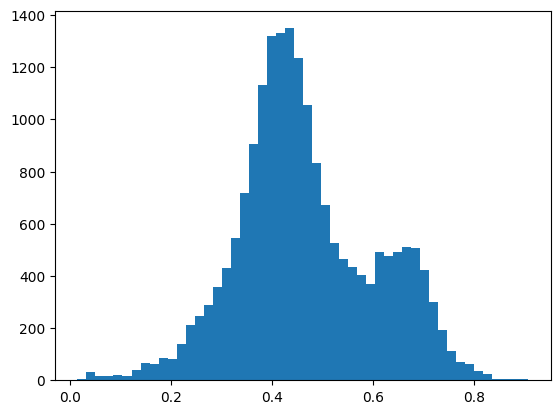

In [23]:
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

plt.hist(y_prob, bins=50)
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print(auc)

0.6357393086813365


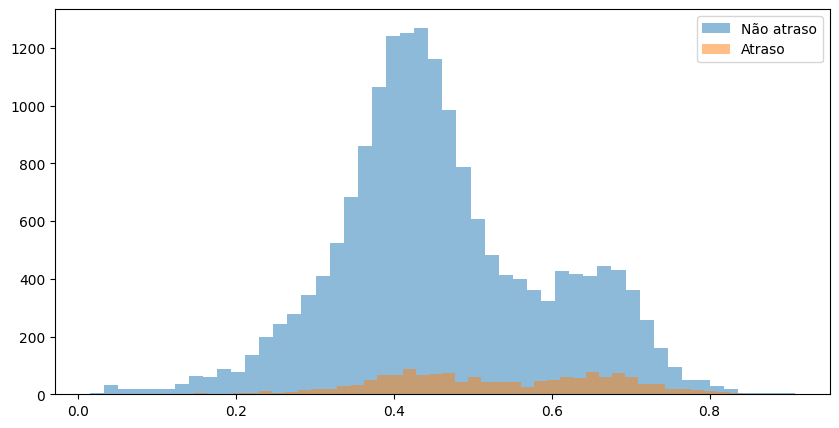

In [25]:
plt.figure(figsize=(10,5))

plt.hist(
    y_prob[y_test==0],
    bins=50,
    alpha=0.5,
    label="Não atraso"
)

plt.hist(
    y_prob[y_test==1],
    bins=50,
    alpha=0.5,
    label="Atraso"
)

plt.legend()
plt.show()

In [26]:
df[["distance_km","is_late_delivery"]].corr()

,distance_km,is_late_delivery
distance_km,1.000000,0.070802
is_late_delivery,0.070802,1.000000


In [27]:
from lightgbm import LGBMClassifier
import pandas as pd

model = LGBMClassifier()

model.fit(X_train, y_train)

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(30)

c:\Users\Lucas\Desktop\Rumo-projeto-pos\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Lucas\Desktop\Rumo-projeto-pos\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Lucas\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lucas\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __ini

[LightGBM] [Info] Number of positive: 6097, number of negative: 70412
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1948
[LightGBM] [Info] Number of data points in the train set: 76509, number of used features: 207
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.079690 -> initscore=-2.446567
[LightGBM] [Info] Start training from score -2.446567


,feature,importance
480,distance_km,382
0,purchase_month,369
3,log_freight,329
4,log_weight,252
5,log_volume,252
6,freight_ratio,228
2,log_price,218
1,purchase_weekday,123
471,route_SP_RJ,45
19,product_category_name_cama_mesa_banho,27


In [28]:

import numpy as np

from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight="balanced", random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, learning_rate=0.05, class_weight="balanced", random_state=42
    )
}

# ======================
# THRESHOLDS
# ======================
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

# ======================
# TRAIN + EVALUATE
# ======================

for name, model in models.items():
    print(f"\n==================== {name} ====================")
    
    # Treinamento
    if name == "Logistic Regression":
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    # Teste de thresholds
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        print(f"\nThreshold: {t}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall:    {recall:.3f}")
        print(f"F1-score:  {f1:.3f}")
        print(f"AUC:       {auc:.3f}")


==================== Logistic Regression ====================

Threshold: 0.3
Precision: 0.084
Recall:    0.957
F1-score:  0.154
AUC:       0.636

Threshold: 0.4
Precision: 0.095
Recall:    0.807
F1-score:  0.169
AUC:       0.636

Threshold: 0.5
Precision: 0.128
Recall:    0.543
F1-score:  0.207
AUC:       0.636

Threshold: 0.6
Precision: 0.148
Recall:    0.369
F1-score:  0.211
AUC:       0.636

Threshold: 0.7
Precision: 0.164
Recall:    0.115
F1-score:  0.135
AUC:       0.636

==================== Decision Tree ====================

Threshold: 0.3
Precision: 0.100
Recall:    0.886
F1-score:  0.180
AUC:       0.710

Threshold: 0.4
Precision: 0.115
Recall:    0.801
F1-score:  0.201
AUC:       0.710

Threshold: 0.5
Precision: 0.154
Recall:    0.629
F1-score:  0.247
AUC:       0.710

Threshold: 0.6
Precision: 0.167
Recall:    0.555
F1-score:  0.257
AUC:       0.710

Threshold: 0.7
Precision: 0.210
Recall:    0.358
F1-score:  0.264
AUC:       0.710

==================== Random Forest ====

c:\Users\Lucas\Desktop\Rumo-projeto-pos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[LightGBM] [Info] Number of positive: 6097, number of negative: 70412
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1948
[LightGBM] [Info] Number of data points in the train set: 76509, number of used features: 207
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

Threshold: 0.3
Precision: 0.108
Recall:    0.904
F1-score:  0.192
AUC:       0.750

Threshold: 0.4
Precision: 0.138
Recall:    0.782
F1-score:  0.235
AUC:       0.750

Threshold: 0.5
Precision: 0.176
Recall:    0.635
F1-score:  0.275
AUC:       0.750

Threshold: 0.6
Precision: 0.215
Recall:    0.489
F1-score:  0.298
AUC:       0.750

Threshold: 0.7
Precision: 0.268
Recall:    0.294
F1-score:  0.281
AUC:       0.750


In [29]:
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [30]:
threshold = 0.6
y_pred = (y_prob >= threshold).astype(int)

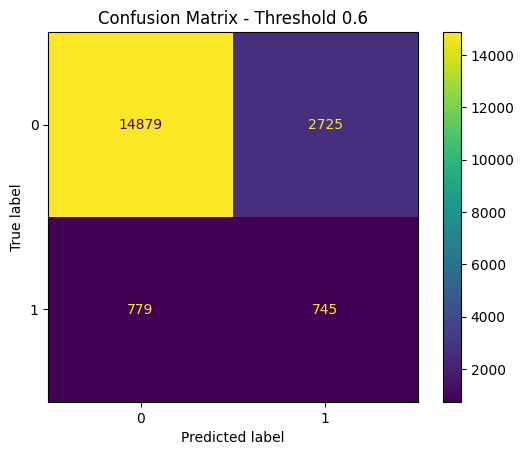

In [31]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    f"Confusion Matrix - Threshold {threshold}"
)

plt.show()

In [32]:
tn, fp, fn, tp = cm.ravel()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

TN: 14879
FP: 2725
FN: 779
TP: 745


In [33]:
print("\n--- BUSINESS VIEW ---")

print(
    f"Pedidos atrasados encontrados: {tp/(tp+fn):.2%}"
)

print(
    f"Alertas incorretos: {fp/(tp+fp):.2%}"
)


--- BUSINESS VIEW ---
Pedidos atrasados encontrados: 48.88%
Alertas incorretos: 78.53%


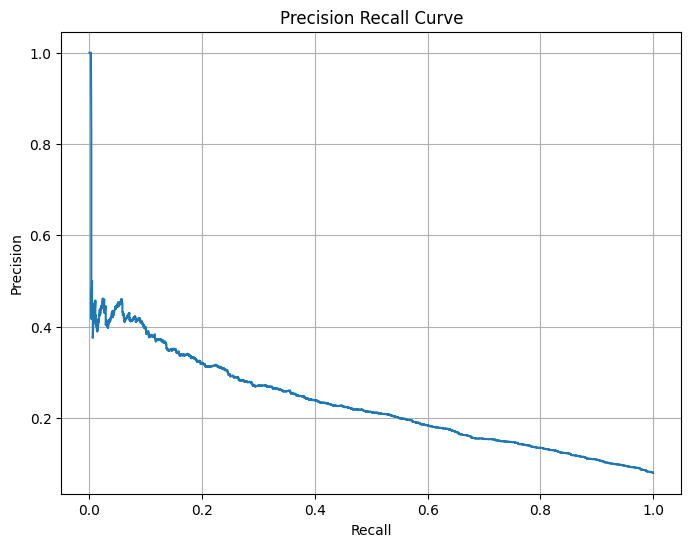

In [34]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision Recall Curve"
)

plt.grid()

plt.show()

In [35]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

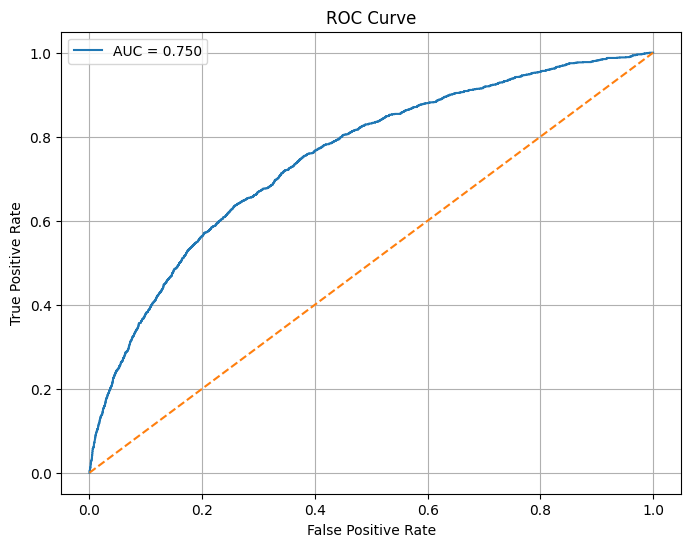

In [36]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

In [38]:
feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

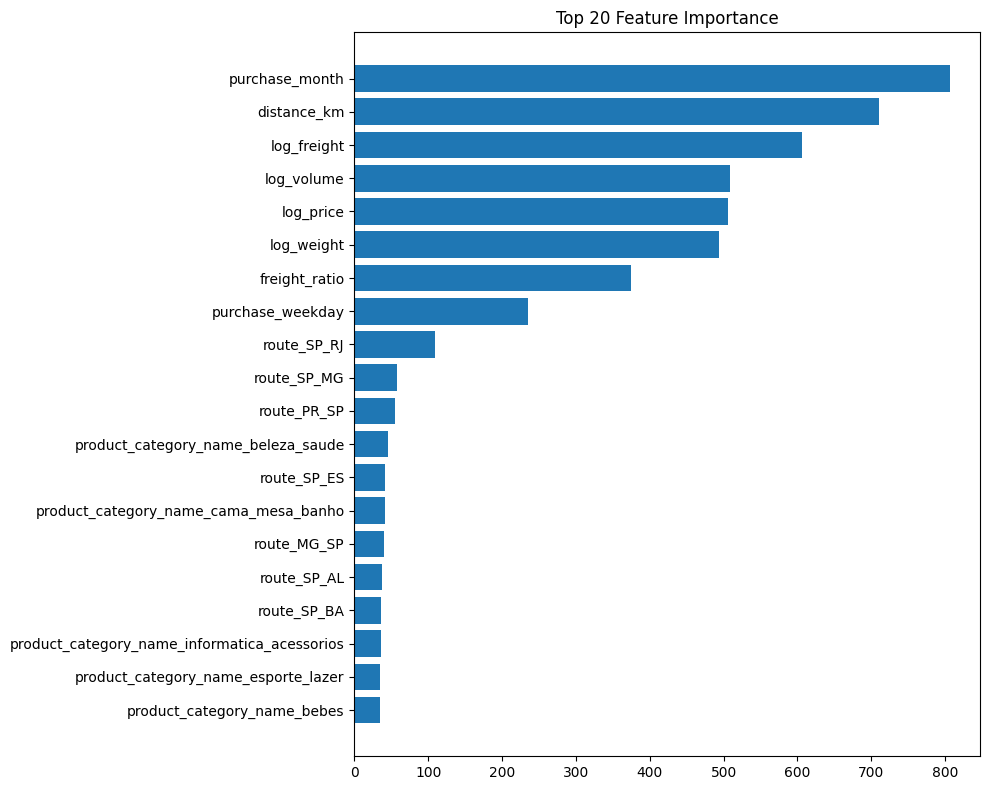

In [39]:
import matplotlib.pyplot as plt

top_features = (
    feature_importance
    .head(20)
)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Feature Importance"
)

plt.tight_layout()

plt.show()

In [40]:
top_features.reset_index(drop=True)

,feature,importance
0,purchase_month,807
1,distance_km,711
2,log_freight,606
3,log_volume,509
4,log_price,506
5,log_weight,494
6,freight_ratio,375
7,purchase_weekday,235
8,route_SP_RJ,109
9,route_SP_MG,58


In [41]:
def classify_feature(feature):

    if feature.startswith("route_"):
        return "route"

    elif feature.startswith("seller_state_"):
        return "seller_state"

    elif feature.startswith("customer_state_"):
        return "customer_state"

    elif feature.startswith("product_category_name"):
        return "category"

    elif feature == "distance_km":
        return "distance"

    else:
        return "other"

In [42]:
feature_importance["group"] = (
    feature_importance["feature"]
    .apply(classify_feature)
)

In [43]:
group_importance = (
    feature_importance
    .groupby("group")
    ["importance"]
    .sum()
    .sort_values(
        ascending=False
    )
)

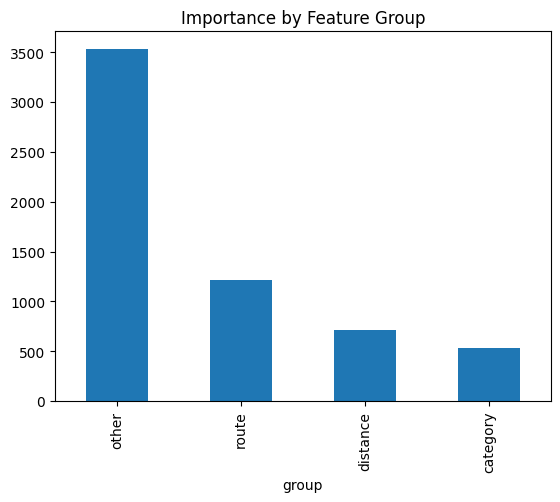

In [44]:
group_importance.plot(
    kind="bar"
)

plt.title(
    "Importance by Feature Group"
)

plt.show()

In [45]:
group_importance

group
other       3532
route       1220
distance     711
category     537
Name: importance, dtype: int32

In [46]:
routes = (
    feature_importance[
        feature_importance["feature"]
        .str.startswith("route_")
    ]
)

In [47]:
print(
    routes.head(20)
)

         feature  importance  group
471  route_SP_RJ         109  route
463  route_SP_MG          58  route
351  route_PR_SP          55  route
460  route_SP_ES          42  route
246  route_MG_SP          40  route
454  route_SP_AL          37  route
457  route_SP_BA          36  route
238  route_MG_PR          33  route
418  route_RS_SP          32  route
476  route_SP_SC          32  route
231  route_MG_MG          32  route
462  route_SP_MA          31  route
344  route_PR_RJ          27  route
444  route_SC_SP          27  route
416  route_RS_SC          27  route
464  route_SP_MS          25  route
470  route_SP_PR          25  route
336  route_PR_MG          24  route
301  route_PE_MG          24  route
465  route_SP_MT          24  route


In [48]:
feature_importance[
    feature_importance["feature"] == "distance_km"
]

,feature,importance,group
480,distance_km,711,distance


In [49]:
import seaborn as sns

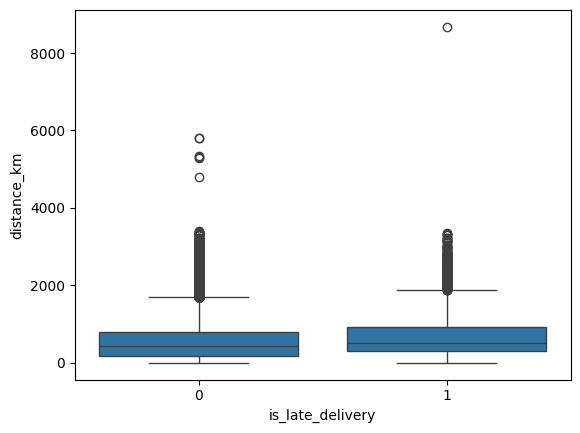

In [50]:
sns.boxplot(
    data=df,
    x="is_late_delivery",
    y="distance_km"
)

plt.show()

In [51]:
df.groupby(
    "is_late_delivery"
)["distance_km"].mean()

is_late_delivery
0    588.149567
1    743.151370
Name: distance_km, dtype: float64

In [52]:
route_cols = [
    c for c in df.columns
    if c.startswith("route_")
]

route_results = []

for col in route_cols:

    subset = df[df[col] == 1]

    route_results.append({
        "route": col.replace("route_", ""),
        "orders": len(subset),
        "late_rate": subset["is_late_delivery"].mean()
    })

route_analysis = (
    pd.DataFrame(route_results)
      .sort_values("orders", ascending=False)
)

print(route_analysis.head(20))

     route  orders  late_rate
399  SP_SP   30510   0.060374
392  SP_RJ    8092   0.154103
384  SP_MG    7341   0.062662
396  SP_RS    3529   0.075942
391  SP_PR    3048   0.050853
272  PR_SP    2989   0.035129
167  MG_SP    2549   0.041977
378  SP_BA    2282   0.148992
397  SP_SC    2254   0.106921
152  MG_MG    1527   0.031434
381  SP_ES    1458   0.135117
382  SP_GO    1403   0.091233
365  SC_SP    1355   0.043542
297  RJ_SP    1332   0.090090
380  SP_DF    1247   0.081796
160  MG_RJ    1131   0.093722
389  SP_PE    1120   0.106250
265  PR_RJ     984   0.138211
379  SP_CE     951   0.148265
291  RJ_RJ     943   0.064687


In [53]:
category_cols = [
    c for c in df.columns
    if c.startswith("product_category_name_")
]

category_results = []

for col in category_cols:

    subset = df[df[col] == 1]

    category_results.append({
        "category": col.replace(
            "product_category_name_",
            ""
        ),
        "orders": len(subset),
        "late_rate": subset["is_late_delivery"].mean()
    })

category_analysis = (
    pd.DataFrame(category_results)
      .sort_values("late_rate", ascending=False)
)

print(category_analysis.head(20))

                             category  orders  late_rate
14                    casa_conforto_2      24   0.166667
51          moveis_colchao_e_estofado      37   0.135135
6                               audio     344   0.130814
38     fashion_underwear_e_moda_praia     118   0.127119
13                      casa_conforto     389   0.107969
48                    livros_tecnicos     260   0.107692
5                    artigos_de_natal     127   0.102362
0                           alimentos     422   0.101896
29                        eletronicos    2432   0.094984
56                        moveis_sala     306   0.091503
8                               bebes    2723   0.090709
54                  moveis_escritorio    1270   0.090551
10                       beleza_saude    8596   0.088297
22  construcao_ferramentas_iluminacao     240   0.087500
44              instrumentos_musicais     606   0.087459
12                    cama_mesa_banho    9844   0.085738
7                          auto

In [54]:
pd.qcut(
    df["distance_km"],
    q=5
)

0         (531.218, 875.839]
1         (347.955, 531.218]
2         (117.281, 347.955]
3         (347.955, 531.218]
4         (117.281, 347.955]
                ...         
95632    (875.839, 8677.912]
95633     (117.281, 347.955]
95634     (531.218, 875.839]
95635     (531.218, 875.839]
95636     (531.218, 875.839]
Name: distance_km, Length: 95637, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 117.281] < (117.281, 347.955] < (347.955, 531.218] < (531.218, 875.839] < (875.839, 8677.912]]

In [55]:
bins = [0,200,500,1000,2000,10000]

df["distance_band"] = pd.cut(
    df["distance_km"],
    bins=bins
)

distance_analysis = (
    df.groupby("distance_band")
      ["is_late_delivery"]
      .mean()
      .reset_index()
)

print(distance_analysis)

   distance_band  is_late_delivery
0       (0, 200]          0.061412
1     (200, 500]          0.072418
2    (500, 1000]          0.082994
3   (1000, 2000]          0.107726
4  (2000, 10000]          0.135082


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5376\369739942.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("distance_band")


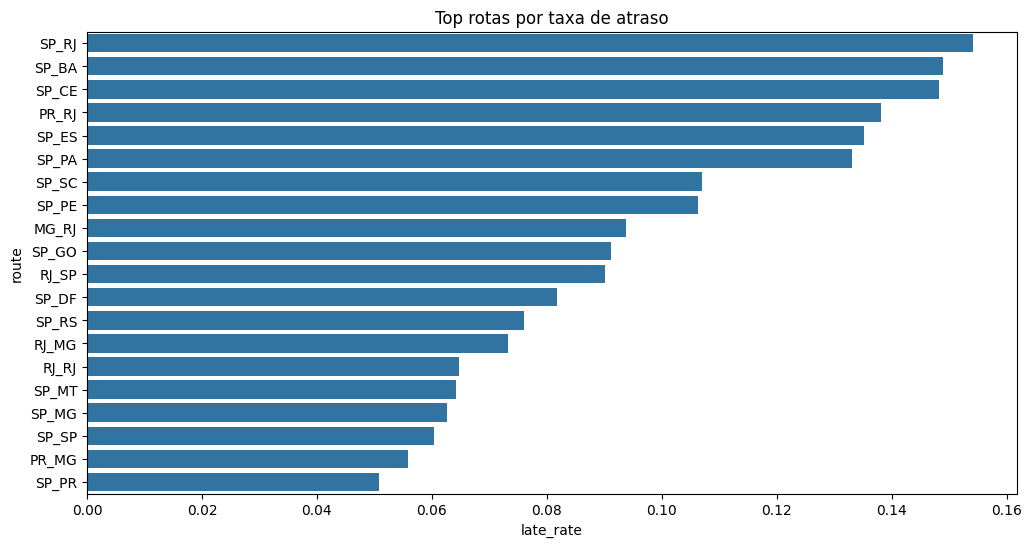

In [56]:
top_routes = (
    route_analysis
    .query("orders >= 500")
    .sort_values("late_rate", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_routes,
    x="late_rate",
    y="route"
)

plt.title("Top rotas por taxa de atraso")
plt.show()

In [57]:
import shap

In [58]:
explainer = shap.TreeExplainer(model)

In [72]:
X_sample = X_test.sample(
    1,
    random_state=42
)

In [73]:
shap_values = explainer.shap_values(X_sample)

c:\Users\Lucas\Desktop\Rumo-projeto-pos\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


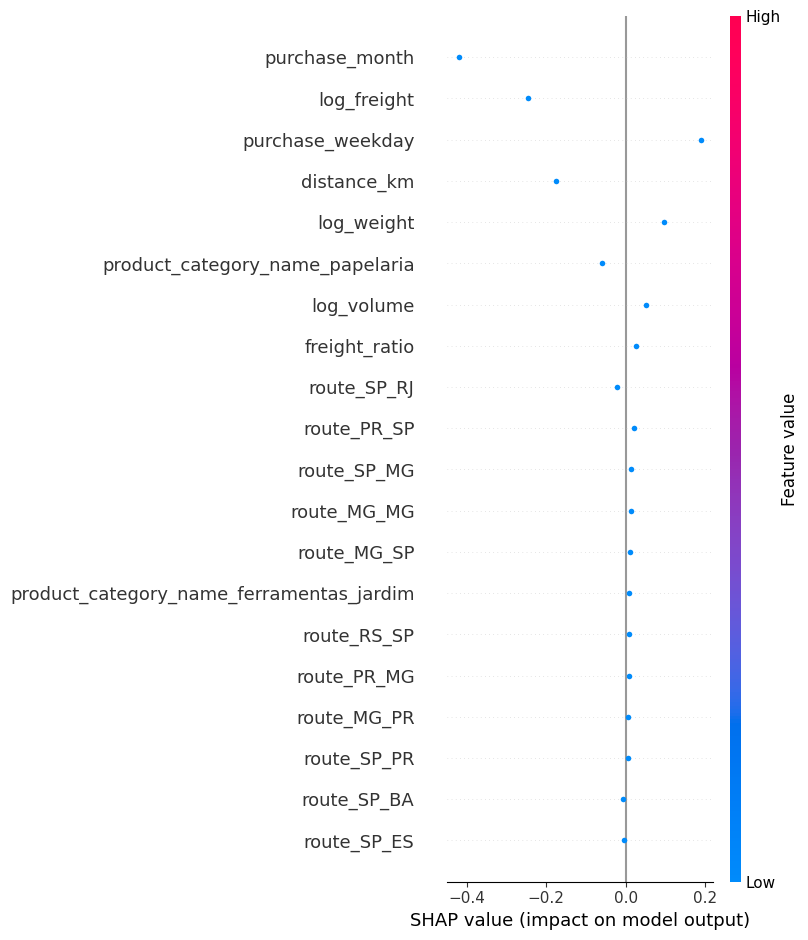

In [74]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [75]:
shap_values

array([[-4.18247704e-01,  1.90282946e-01,  7.47639892e-04,
        -2.45673637e-01,  9.59785908e-02,  5.16795015e-02,
         2.65364210e-02, -1.99537314e-04,  4.70241252e-04,
        -7.01915098e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -2.60203613e-04, -6.62974788e-05,
        -1.70329193e-03, -2.53408248e-06,  1.50625000e-05,
         1.70557054e-03,  2.42887688e-03,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.82182415e-03, -5.32795900e-05,
         0.00000000e+00,  0.00000000e+00, -7.40907641e-05,
         7.79059713e-05,  6.11471229e-04,  1.54717891e-03,
         0.00000000e+00,  1.33749035e-03,  9.77179180e-05,
        -2.21542374e-04,  1.11393563e-04, -4.20981329e-04,
         1.21245695e-03,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  8.57409026e-03,  1.98701884e-05,
         0.00000000e+00,  0.00000000e+00,  2.61801939e-0

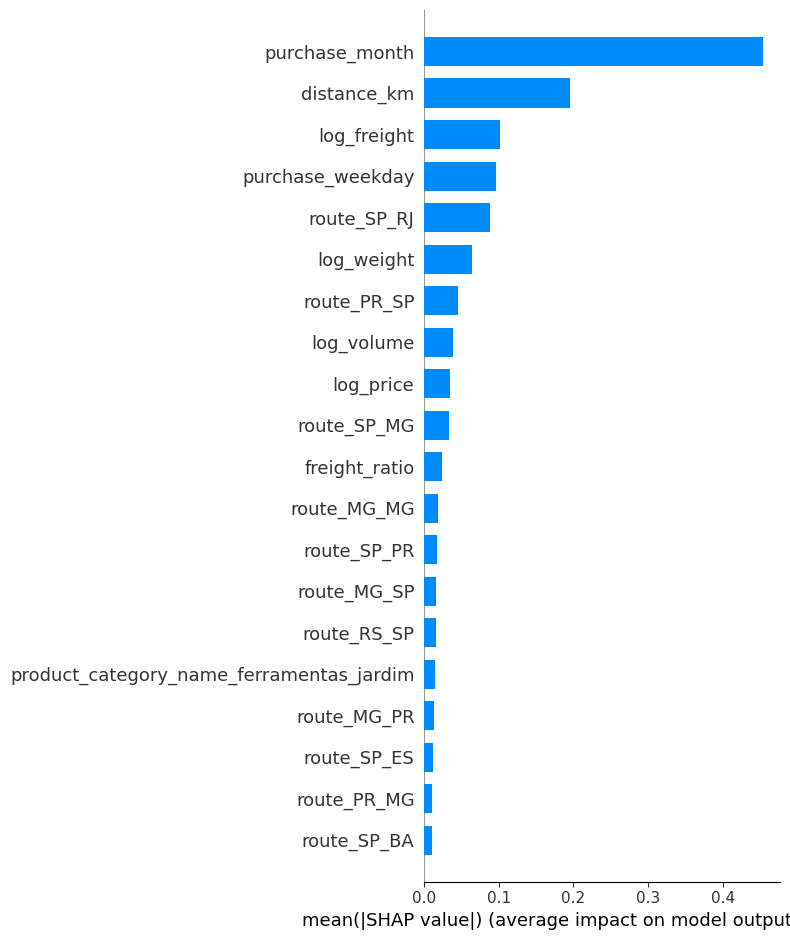

In [62]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

In [63]:
row = X_sample.iloc[[0]]

In [64]:
prob = model.predict_proba(row)[0,1]

print(prob)

0.29185983329996135


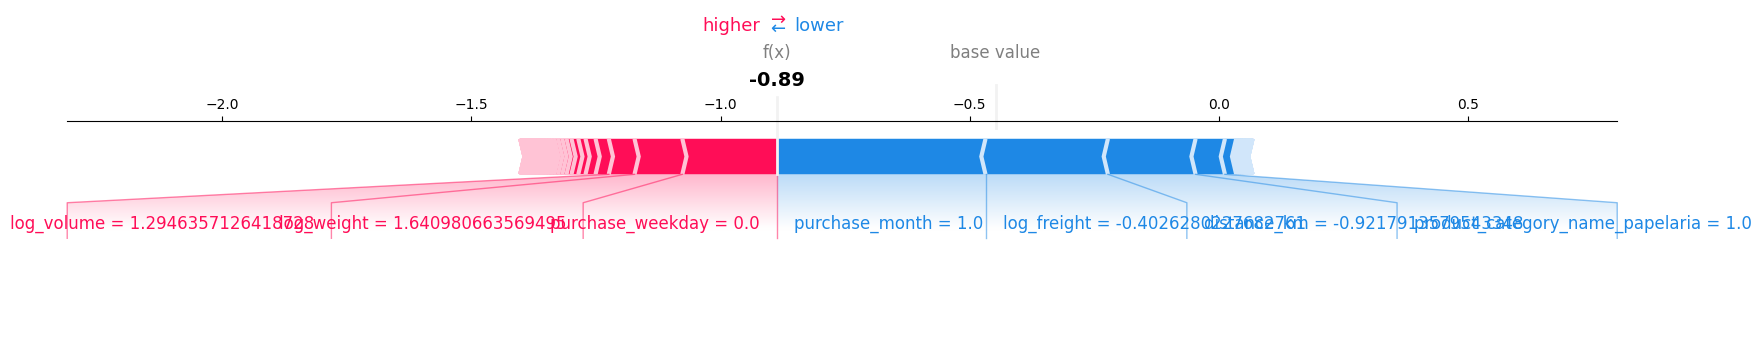

In [65]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    row,
    matplotlib=True
)

In [66]:
shap_importance = pd.DataFrame({
    "feature": X_sample.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

print(shap_importance.head(20))

                                      feature  importance
0                              purchase_month    0.454206
480                               distance_km    0.195840
3                                 log_freight    0.101445
1                            purchase_weekday    0.096370
471                               route_SP_RJ    0.088164
4                                  log_weight    0.064130
351                               route_PR_SP    0.044762
5                                  log_volume    0.038549
2                                   log_price    0.034413
463                               route_SP_MG    0.033418
6                               freight_ratio    0.024350
231                               route_MG_MG    0.018170
470                               route_SP_PR    0.016488
246                               route_MG_SP    0.015594
418                               route_RS_SP    0.015435
46   product_category_name_ferramentas_jardim    0.015043
238           

In [76]:
shap_values = explainer(X_sample)

In [77]:
shap_values

.values =
array([[-4.18247704e-01,  1.90282946e-01,  7.47639892e-04,
        -2.45673637e-01,  9.59785908e-02,  5.16795015e-02,
         2.65364210e-02, -1.99537314e-04,  4.70241252e-04,
        -7.01915098e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -2.60203613e-04, -6.62974788e-05,
        -1.70329193e-03, -2.53408248e-06,  1.50625000e-05,
         1.70557054e-03,  2.42887688e-03,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.82182415e-03, -5.32795900e-05,
         0.00000000e+00,  0.00000000e+00, -7.40907641e-05,
         7.79059713e-05,  6.11471229e-04,  1.54717891e-03,
         0.00000000e+00,  1.33749035e-03,  9.77179180e-05,
        -2.21542374e-04,  1.11393563e-04, -4.20981329e-04,
         1.21245695e-03,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  8.57409026e-03,  1.98701884e-05,
         0.00000000e+00,  0.00000000e+00,  2.6